# DRIVE: joint segment-level + pixel-wise loss

Новый ноутбук для проверки идеи из статьи **Yan, Yang, Cheng — Joint Segment-level and Pixel-wise Losses for Retinal Vessel Segmentation**.

Что проверяется:

1. **U-Net ResNet34 + joint pixel/segment-level loss**.
2. **SA-UNetv2 + joint pixel/segment-level loss**.
3. Сохранение новых `.pth` и `.csv` прямо в папку `drive_segmentation_project_results`, чтобы их можно было сравнить с уже обученными моделями из предыдущего ноутбука.




In [ ]:
import os
import re
import random
import zipfile
from pathlib import Path
import copy
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

try:
    import segmentation_models_pytorch as smp
except ImportError:
    !pip -q install segmentation-models-pytorch
    import segmentation_models_pytorch as smp

try:
    import skimage
    from skimage.morphology import skeletonize, disk
    from skimage import measure
except ImportError:
    !pip -q install scikit-image
    from skimage.morphology import skeletonize, disk
    from skimage import measure

try:
    from scipy.ndimage import binary_dilation, convolve, distance_transform_edt
except ImportError:
    !pip -q install scipy
    from scipy.ndimage import binary_dilation, convolve, distance_transform_edt

warnings.filterwarnings("ignore")

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Для скорости на GPU.
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.6 MB/s eta 0:00:00
Device: cpu


In [ ]:

DATA_ZIP_PATH = None 
RESULTS_DIR_NAME = "drive_segmentation_project_results"
DATA_DIR = Path("drive_dataset_extracted")


def _candidate_roots():
    roots = [Path("."), Path("/content"), Path("/mnt/data")]
    unique_roots = []
    for root in roots:
        if root.exists() and root not in unique_roots:
            unique_roots.append(root)
    return unique_roots


def find_dataset_zip(data_zip_path=None):
    if data_zip_path is not None:
        path = Path(data_zip_path)
        if path.exists():
            return path
        raise FileNotFoundError(f"DATA_ZIP_PATH указан, но файл не найден: {path}")

    patterns = [
        "DRIVE.zip",
        "DRIVE*.zip",
        "drive*.zip",
        "datasets*.zip",
    ]

    candidates = []
    for root in _candidate_roots():
        for pattern in patterns:
            candidates.extend(root.glob(pattern))

    
    candidates = [
        p for p in candidates
        if "result" not in p.name.lower()
        and "checkpoint" not in p.name.lower()
        and "model" not in p.name.lower()
    ]

    candidates = sorted(set(candidates), key=lambda p: (p.name.lower() != "drive.zip", len(str(p)), str(p)))

    if len(candidates) == 0:
        raise FileNotFoundError(
            "Не найден архив датасета. Положи DRIVE.zip в корень ноутбука "
            "или пропиши путь вручную в DATA_ZIP_PATH."
        )

    return candidates[0]


def find_or_create_results_dir(results_dir_name=RESULTS_DIR_NAME):
    # 1) если папка уже есть — используем ее
    for root in _candidate_roots():
        folder = root / results_dir_name
        if folder.exists() and folder.is_dir():
            return folder

    # 2) если есть zip с результатами — распакуем
    for root in _candidate_roots():
        for zip_path in root.glob(f"{results_dir_name}*.zip"):
            out_dir = Path(".") / results_dir_name
            out_dir.mkdir(exist_ok=True)
            with zipfile.ZipFile(zip_path, "r") as z:
                z.extractall(out_dir)
            return out_dir

    # 3) если ничего нет — создаем новую папку
    out_dir = Path(".") / results_dir_name
    out_dir.mkdir(exist_ok=True)
    return out_dir


def extract_zip_once(zip_path, out_dir):
    out_dir.mkdir(exist_ok=True)
    marker = out_dir / ".extracted_from_drive_zip"

    
    if not marker.exists():
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(out_dir)
        marker.write_text(str(zip_path), encoding="utf-8")

    
    nested_zips = list(out_dir.rglob("*.zip"))
    for nested_zip in nested_zips:
        if nested_zip.name.lower() in {"training.zip", "test.zip"}:
            nested_marker = nested_zip.with_suffix(nested_zip.suffix + ".extracted")
            if not nested_marker.exists():
                with zipfile.ZipFile(nested_zip, "r") as z:
                    z.extractall(nested_zip.parent)
                nested_marker.write_text("done", encoding="utf-8")


def find_dir_by_suffix(root, suffix_parts):
    suffix_parts = tuple(suffix_parts)
    matches = []
    for p in root.rglob("*"):
        if p.is_dir() and tuple(p.parts[-len(suffix_parts):]) == suffix_parts:
            matches.append(p)
    if len(matches) == 0:
        raise FileNotFoundError(f"Не найдена папка с окончанием: {'/'.join(suffix_parts)} внутри {root}")
    return sorted(matches, key=lambda x: len(str(x)))[0]


DATA_ZIP = find_dataset_zip(DATA_ZIP_PATH)
OUTPUT_DIR = find_or_create_results_dir(RESULTS_DIR_NAME)
extract_zip_once(DATA_ZIP, DATA_DIR)

TRAIN_IMG_DIR = find_dir_by_suffix(DATA_DIR, ("training", "images"))
TRAIN_GT_DIR = find_dir_by_suffix(DATA_DIR, ("training", "1st_manual"))
TRAIN_FOV_DIR = find_dir_by_suffix(DATA_DIR, ("training", "mask"))


def get_image_id(path):
    match = re.search(r"\d+", path.name)
    if match is None:
        raise ValueError(f"Не удалось извлечь id из имени файла: {path.name}")
    return match.group(0)


train_images = {get_image_id(p): p for p in sorted(TRAIN_IMG_DIR.glob("*.tif"))}
train_gt = {get_image_id(p): p for p in sorted(TRAIN_GT_DIR.glob("*.gif"))}
train_fov = {get_image_id(p): p for p in sorted(TRAIN_FOV_DIR.glob("*.gif"))}

common_ids = sorted(
    set(train_images.keys()) & set(train_gt.keys()) & set(train_fov.keys()),
    key=lambda x: int(x)
)

print("Dataset archive:", DATA_ZIP)
print("Extracted to:", DATA_DIR.resolve())
print("Results folder:", OUTPUT_DIR.resolve())
print("Train image dir:", TRAIN_IMG_DIR)
print("GT mask dir:", TRAIN_GT_DIR)
print("FOV mask dir:", TRAIN_FOV_DIR)
print("Train image-mask pairs:", len(common_ids))

old_pth_files = sorted(OUTPUT_DIR.glob("*.pth"))
old_csv_files = sorted(OUTPUT_DIR.glob("*.csv"))
print("Existing .pth files in results folder:", len(old_pth_files))
for p in old_pth_files:
    print(" -", p.name)

assert len(common_ids) > 0, "Не удалось собрать пары image / ground truth / FOV mask."


Dataset archive: DRIVE.zip
Extracted to: /content/drive_dataset_extracted
Results folder: /content/drive_segmentation_project_results
Train image dir: drive_dataset_extracted/DRIVE/training/images
GT mask dir: drive_dataset_extracted/DRIVE/training/1st_manual
FOV mask dir: drive_dataset_extracted/DRIVE/training/mask
Train image-mask pairs: 20
Existing .pth files in results folder: 0


## Segment-level часть

Оригинальная статья делает так:

1. строит skeleton по ground truth;
2. делит vessel tree на сегменты;
3. для каждого сегмента считает среднюю толщину;
4. сравнивает толщину сегмента в ground truth и в prediction;
5. увеличивает веса там, где есть mismatch по толщине.

В этом ноутбуке реализована практическая PyTorch-адаптация:

\[
L = \alpha \cdot L_{pixel} + \beta \cdot L_{segment}
\]

где `pixel_loss` — обычный BCE внутри FOV, а `segment_loss` — weighted L1 между probability map и mask. Веса строятся по mismatch ratio сосудистых сегментов.


In [ ]:

def read_rgb_image(path, image_size=(512, 512)):
    image = Image.open(path).convert("RGB")
    image = image.resize(image_size, Image.BILINEAR)
    return np.array(image)


def read_binary_mask(path, image_size=(512, 512)):
    mask = Image.open(path).convert("L")
    mask = mask.resize(image_size, Image.NEAREST)
    mask = np.array(mask)
    return (mask > 0).astype(np.uint8)


def build_segment_target_maps(mask_np, fov_np=None, max_length=64, radius=2):
    """
    Builds maps needed for the segment-level loss.

    Returns:
    - search_id_map: segment id assigned to pixels in search range Ri.
    - skel_len_map: skeleton length |Si| for the corresponding segment.
    - tv_gt_map: ground-truth thickness TVi = |Vi| / |Si|.

    This is a practical approximation of the segment construction from the paper.
    """
    mask = mask_np.astype(bool)

    if fov_np is not None:
        fov = fov_np.astype(bool)
        mask = mask & fov
    else:
        fov = np.ones_like(mask, dtype=bool)

    h, w = mask.shape

    search_id_map = np.zeros((h, w), dtype=np.int32)
    skel_len_map = np.zeros((h, w), dtype=np.float32)
    tv_gt_map = np.zeros((h, w), dtype=np.float32)

    if mask.sum() == 0:
        return search_id_map, skel_len_map, tv_gt_map

    skeleton = skeletonize(mask)

    if skeleton.sum() == 0:
        return search_id_map, skel_len_map, tv_gt_map

    # Branch pixels: skeleton pixels with >= 3 neighbors.
    kernel = np.ones((3, 3), dtype=np.uint8)
    neighbor_count = convolve(skeleton.astype(np.uint8), kernel, mode="constant", cval=0)
    neighbor_count = neighbor_count - skeleton.astype(np.uint8)

    branch_pixels = skeleton & (neighbor_count >= 3)
    skeleton_wo_branches = skeleton & (~branch_pixels)

    labeled = measure.label(skeleton_wo_branches, connectivity=2)

   
    segment_skeleton = np.zeros_like(labeled, dtype=np.int32)
    new_id = 1

    for label_id in range(1, labeled.max() + 1):
        coords = np.argwhere(labeled == label_id)

        if len(coords) < 2:
            continue

       
        coords = coords[np.lexsort((coords[:, 1], coords[:, 0]))]

        if max_length is not None and len(coords) > max_length:
            chunks = [coords[i:i + max_length] for i in range(0, len(coords), max_length)]
        else:
            chunks = [coords]

        for chunk in chunks:
            if len(chunk) < 2:
                continue
            segment_skeleton[chunk[:, 0], chunk[:, 1]] = new_id
            new_id += 1

    
    if segment_skeleton.max() == 0:
        segment_skeleton[skeleton] = 1

    
    skeleton_pixels = segment_skeleton > 0
    _, nearest_indices = distance_transform_edt(~skeleton_pixels, return_indices=True)
    nearest_segment = segment_skeleton[nearest_indices[0], nearest_indices[1]]
    vessel_segment_map = np.where(mask, nearest_segment, 0).astype(np.int32)

    struct = disk(radius).astype(bool)

    for sid in range(1, int(segment_skeleton.max()) + 1):
        skel_region = segment_skeleton == sid
        skel_len = float(skel_region.sum())

        if skel_len <= 0:
            continue

        vessel_region = vessel_segment_map == sid
        gt_area = float(vessel_region.sum())

        if gt_area <= 0:
            continue

        tv_gt = gt_area / skel_len

       
        search_region = binary_dilation(skel_region, structure=struct)
        search_region = search_region | vessel_region
        search_region = search_region & fov

       
        search_id_map[search_region] = sid
        skel_len_map[search_region] = skel_len
        tv_gt_map[search_region] = tv_gt

    return search_id_map, skel_len_map, tv_gt_map


In [ ]:
class DriveSegmentationJointDataset(Dataset):
    def __init__(
        self,
        image_ids,
        image_paths,
        mask_paths,
        fov_paths,
        image_size=(512, 512),
        max_length=64,
        search_radius=2,
        precompute_segments=True
    ):
        self.image_ids = list(image_ids)
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.fov_paths = fov_paths
        self.image_size = image_size
        self.max_length = max_length
        self.search_radius = search_radius

        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

        self.segment_cache = {}

        if precompute_segments:
            print(f"Precomputing segment maps for {len(self.image_ids)} images...")
            for image_id in tqdm(self.image_ids, leave=False):
                mask_np = read_binary_mask(self.mask_paths[image_id], self.image_size)
                fov_np = read_binary_mask(self.fov_paths[image_id], self.image_size)

                search_id, skel_len, tv_gt = build_segment_target_maps(
                    mask_np=mask_np,
                    fov_np=fov_np,
                    max_length=self.max_length,
                    radius=self.search_radius
                )

                self.segment_cache[image_id] = {
                    "segment_id": search_id,
                    "segment_skel_len": skel_len,
                    "segment_tv_gt": tv_gt
                }

    def __len__(self):
        return len(self.image_ids)

    def _read_image_tensor(self, path):
        image = read_rgb_image(path, self.image_size).astype(np.float32) / 255.0
        image = torch.from_numpy(image).permute(2, 0, 1)
        image = (image - self.mean) / self.std
        return image

    def _read_mask_tensor(self, path):
        mask = read_binary_mask(path, self.image_size).astype(np.float32)
        return torch.from_numpy(mask).unsqueeze(0)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]

        image = self._read_image_tensor(self.image_paths[image_id])
        mask = self._read_mask_tensor(self.mask_paths[image_id])
        fov = self._read_mask_tensor(self.fov_paths[image_id])

        if image_id not in self.segment_cache:
            mask_np = mask.squeeze(0).numpy().astype(np.uint8)
            fov_np = fov.squeeze(0).numpy().astype(np.uint8)
            search_id, skel_len, tv_gt = build_segment_target_maps(
                mask_np=mask_np,
                fov_np=fov_np,
                max_length=self.max_length,
                radius=self.search_radius
            )
        else:
            cached = self.segment_cache[image_id]
            search_id = cached["segment_id"]
            skel_len = cached["segment_skel_len"]
            tv_gt = cached["segment_tv_gt"]

        return {
            "image_id": image_id,
            "image": image,
            "mask": mask,
            "fov": fov,
            "segment_id": torch.from_numpy(search_id).long().unsqueeze(0),
            "segment_skel_len": torch.from_numpy(skel_len).float().unsqueeze(0),
            "segment_tv_gt": torch.from_numpy(tv_gt).float().unsqueeze(0),
        }


IMAGE_SIZE = (512, 512)
BATCH_SIZE = 2

train_ids, val_ids = train_test_split(
    common_ids,
    test_size=0.2,
    random_state=SEED,
    shuffle=True
)

print("Train images:", len(train_ids), train_ids)
print("Val images:", len(val_ids), val_ids)

train_dataset = DriveSegmentationJointDataset(
    image_ids=train_ids,
    image_paths=train_images,
    mask_paths=train_gt,
    fov_paths=train_fov,
    image_size=IMAGE_SIZE,
    max_length=64,
    search_radius=2,
    precompute_segments=True
)

val_dataset = DriveSegmentationJointDataset(
    image_ids=val_ids,
    image_paths=train_images,
    mask_paths=train_gt,
    fov_paths=train_fov,
    image_size=IMAGE_SIZE,
    max_length=64,
    search_radius=2,
    precompute_segments=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

batch = next(iter(train_loader))
for key, value in batch.items():
    if torch.is_tensor(value):
        print(key, tuple(value.shape), value.dtype)


Train images: 16 ['29', '26', '32', '24', '39', '37', '34', '23', '30', '40', '25', '33', '28', '31', '35', '27']
Val images: 4 ['21', '38', '36', '22']
Precomputing segment maps for 16 images...


  0%|          | 0/16 [00:00<?, ?it/s]

Precomputing segment maps for 4 images...


  0%|          | 0/4 [00:00<?, ?it/s]

image (2, 3, 512, 512) torch.float32
mask (2, 1, 512, 512) torch.float32
fov (2, 1, 512, 512) torch.float32
segment_id (2, 1, 512, 512) torch.int64
segment_skel_len (2, 1, 512, 512) torch.float32
segment_tv_gt (2, 1, 512, 512) torch.float32


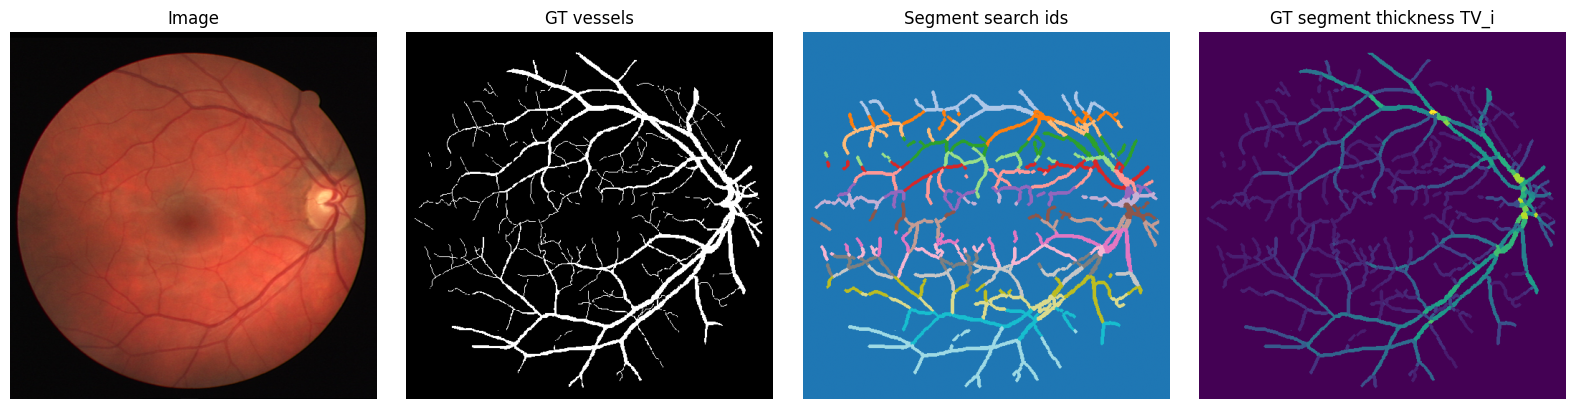

Number of segment ids: 496
Non-zero TV_i stats: count    39734.000000
mean         3.473878
std          2.541103
min          1.000000
25%          1.285714
50%          2.675676
75%          5.238095
max         14.000000
dtype: float64


In [ ]:
def denormalize_image(image_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    image = image_tensor.detach().cpu()
    image = image * std + mean
    image = image.clamp(0, 1)
    image = image.permute(1, 2, 0).numpy()
    return image

sample = train_dataset[0]

image = denormalize_image(sample["image"])
mask = sample["mask"].squeeze().numpy()
fov = sample["fov"].squeeze().numpy()
segment_id = sample["segment_id"].squeeze().numpy()
tv_gt = sample["segment_tv_gt"].squeeze().numpy()

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(mask, cmap="gray")
plt.title("GT vessels")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(segment_id, cmap="tab20")
plt.title("Segment search ids")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(tv_gt * fov, cmap="viridis")
plt.title("GT segment thickness TV_i")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Number of segment ids:", int(segment_id.max()))
print("Non-zero TV_i stats:", pd.Series(tv_gt[tv_gt > 0].reshape(-1)).describe())


In [ ]:
class UNetResNet34TwoHead(nn.Module):
    """
    Shared U-Net encoder/decoder with 2 output channels:
    channel 0 = pixel-wise branch,
    channel 1 = segment-level branch.
    """
    def __init__(self, encoder_weights="imagenet"):
        super().__init__()
        self.model = smp.Unet(
            encoder_name="resnet34",
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=2,
            activation=None
        )

    def forward(self, x):
        return self.model(x)


class DropBlock2D(nn.Module):
    def __init__(self, drop_prob=0.15, block_size=7):
        super().__init__()
        self.drop_prob = drop_prob
        self.block_size = block_size

    def forward(self, x):
        if not self.training or self.drop_prob == 0.0:
            return x

        gamma = self.drop_prob / (self.block_size ** 2)

        mask = (torch.rand(
            x.shape[0], 1, x.shape[2], x.shape[3],
            device=x.device
        ) < gamma).float()

        block_mask = F.max_pool2d(
            mask,
            kernel_size=self.block_size,
            stride=1,
            padding=self.block_size // 2
        )

        block_mask = 1 - block_mask
        return x * block_mask * (block_mask.numel() / block_mask.sum().clamp_min(1.0))


def make_group_norm(channels):
    groups = 8
    while channels % groups != 0:
        groups -= 1
    return nn.GroupNorm(groups, channels)


class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, drop_prob=0.15, block_size=7):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            DropBlock2D(drop_prob=drop_prob, block_size=block_size),
            make_group_norm(out_channels),
            nn.SiLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            DropBlock2D(drop_prob=drop_prob, block_size=block_size),
            make_group_norm(out_channels),
            nn.SiLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class CrossScaleSpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=2,
            out_channels=1,
            kernel_size=7,
            padding=3,
            bias=True
        )

    def forward(self, encoder_feature, decoder_feature):
        encoder_avg = torch.mean(encoder_feature, dim=1, keepdim=True)
        decoder_avg = torch.mean(decoder_feature, dim=1, keepdim=True)

        attention_input = torch.cat([encoder_avg, decoder_avg], dim=1)
        attention_map = torch.sigmoid(self.conv(attention_input))

        return encoder_feature * attention_map


class SAUNetV2(nn.Module):
    """
    SA-UNetv2 from the previous notebook, but out_channels=2 for two heads.
    """
    def __init__(
        self,
        in_channels=3,
        out_channels=2,
        channels=(16, 32, 48, 64),
        drop_prob=0.15,
        block_size=7
    ):
        super().__init__()

        c1, c2, c3, c4 = channels

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc1 = ConvBlock(in_channels, c1, drop_prob, block_size)
        self.enc2 = ConvBlock(c1, c2, drop_prob, block_size)
        self.enc3 = ConvBlock(c2, c3, drop_prob, block_size)
        self.bottleneck = ConvBlock(c3, c4, drop_prob, block_size)

        self.up3 = nn.ConvTranspose2d(c4, c3, kernel_size=2, stride=2)
        self.csa3 = CrossScaleSpatialAttention()
        self.dec3 = ConvBlock(c3 + c3, c3, drop_prob, block_size)

        self.up2 = nn.ConvTranspose2d(c3, c2, kernel_size=2, stride=2)
        self.csa2 = CrossScaleSpatialAttention()
        self.dec2 = ConvBlock(c2 + c2, c2, drop_prob, block_size)

        self.up1 = nn.ConvTranspose2d(c2, c1, kernel_size=2, stride=2)
        self.csa1 = CrossScaleSpatialAttention()
        self.dec1 = ConvBlock(c1 + c1, c1, drop_prob, block_size)

        self.out_conv = nn.Conv2d(c1, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        e3_att = self.csa3(e3, d3)
        d3 = self.dec3(torch.cat([d3, e3_att], dim=1))

        d2 = self.up2(d3)
        e2_att = self.csa2(e2, d2)
        d2 = self.dec2(torch.cat([d2, e2_att], dim=1))

        d1 = self.up1(d2)
        e1_att = self.csa1(e1, d1)
        d1 = self.dec1(torch.cat([d1, e1_att], dim=1))

        logits = self.out_conv(d1)
        return logits


def split_joint_output(outputs):
    """
    Returns pixel_logits and segment_logits.
    """
    if isinstance(outputs, (tuple, list)):
        return outputs[0], outputs[1]

    if outputs.shape[1] == 2:
        return outputs[:, 0:1], outputs[:, 1:2]

    
    return outputs, outputs


def joint_probability(outputs):
    """
    Inference rule from the paper: multiply probability maps from two branches.
    """
    pixel_logits, segment_logits = split_joint_output(outputs)
    pixel_prob = torch.sigmoid(pixel_logits)
    segment_prob = torch.sigmoid(segment_logits)

    is_tuple_output = isinstance(outputs, (tuple, list))
    is_two_channel_output = (not is_tuple_output) and (outputs.shape[1] == 2)

    if is_tuple_output or is_two_channel_output:
        return pixel_prob * segment_prob

    return pixel_prob


In [ ]:
class JointSegmentPixelLoss(nn.Module):
    def __init__(
        self,
        pixel_weight=0.5,
        segment_weight=0.5,
        threshold=0.5,
        max_adaptive_weight=10.0,
        eps=1e-7
    ):
        super().__init__()
        self.pixel_weight = pixel_weight
        self.segment_weight = segment_weight
        self.threshold = threshold
        self.max_adaptive_weight = max_adaptive_weight
        self.eps = eps

    def build_adaptive_weight_map(
        self,
        segment_logits,
        fovs,
        segment_ids,
        segment_skel_lens,
        segment_tv_gt
    ):
        """
        Builds adaptive weight map according to segment thickness mismatch.

        For every ground-truth vessel segment:
        TV_gt = |V_i| / |S_i|
        TV_pred = predicted pixels inside search range / |S_i|
        mr = |TV_pred - TV_gt| / TV_gt
        weight = 1 + mr

        The weight is applied to the search range of the segment.
        """
        with torch.no_grad():
            probs = torch.sigmoid(segment_logits)
            pred_bin = (probs > self.threshold) & (fovs > 0.5)

            weight_map = torch.ones_like(segment_logits)

            batch_size = segment_logits.shape[0]

            for b in range(batch_size):
                ids = torch.unique(segment_ids[b])
                ids = ids[ids > 0]

                for sid in ids:
                    region = segment_ids[b] == sid

                    if region.sum() == 0:
                        continue

                    skel_len = segment_skel_lens[b][region].max().clamp_min(1.0)
                    tv_gt = segment_tv_gt[b][region].max().clamp_min(self.eps)

                    pred_count = (pred_bin[b] & region).float().sum()
                    tv_pred = pred_count / skel_len

                    mismatch_ratio = torch.abs(tv_pred - tv_gt) / tv_gt
                    adaptive_weight = torch.clamp(
                        1.0 + mismatch_ratio,
                        min=1.0,
                        max=self.max_adaptive_weight
                    )

                    weight_map[b][region] = torch.maximum(
                        weight_map[b][region],
                        adaptive_weight
                    )

            weight_map = torch.where(fovs > 0.5, weight_map, torch.zeros_like(weight_map))
            return weight_map

    def forward(
        self,
        outputs,
        masks,
        fovs,
        segment_ids,
        segment_skel_lens,
        segment_tv_gt
    ):
        pixel_logits, segment_logits = split_joint_output(outputs)

        # 1. Pixel-wise BCE branch.
        pixel_bce = F.binary_cross_entropy_with_logits(
            pixel_logits,
            masks,
            reduction="none"
        )
        pixel_loss = (pixel_bce * fovs).sum() / fovs.sum().clamp_min(1.0)

        # 2. Segment-level branch.
        weight_map = self.build_adaptive_weight_map(
            segment_logits=segment_logits,
            fovs=fovs,
            segment_ids=segment_ids,
            segment_skel_lens=segment_skel_lens,
            segment_tv_gt=segment_tv_gt
        )

        segment_prob = torch.sigmoid(segment_logits)
        segment_abs_error = torch.abs(segment_prob - masks)
        segment_loss = (segment_abs_error * weight_map).sum() / fovs.sum().clamp_min(1.0)

        total_loss = self.pixel_weight * pixel_loss + self.segment_weight * segment_loss

        return total_loss


In [ ]:
def compute_segmentation_metrics_from_probs(probs, masks, fovs, threshold=0.5, eps=1e-7):
    preds = (probs > threshold).float()

    valid = fovs > 0.5
    preds_flat = preds[valid]
    masks_flat = masks[valid]

    tp = (preds_flat * masks_flat).sum()
    fp = (preds_flat * (1 - masks_flat)).sum()
    fn = ((1 - preds_flat) * masks_flat).sum()
    tn = ((1 - preds_flat) * (1 - masks_flat)).sum()

    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    iou = tp / (tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    accuracy = (tp + tn) / (tp + tn + fp + fn + eps)

    return {
        "dice": dice.item(),
        "iou": iou.item(),
        "precision": precision.item(),
        "recall": recall.item(),
        "accuracy": accuracy.item()
    }


def move_batch_to_device(batch, device):
    return {
        "image_id": batch["image_id"],
        "image": batch["image"].to(device),
        "mask": batch["mask"].to(device),
        "fov": batch["fov"].to(device),
        "segment_id": batch["segment_id"].to(device),
        "segment_skel_len": batch["segment_skel_len"].to(device),
        "segment_tv_gt": batch["segment_tv_gt"].to(device),
    }


def train_one_epoch_joint(model, loader, optimizer, loss_fn, device):
    model.train()

    total_loss = 0.0
    total_metrics = {
        "dice": 0.0,
        "iou": 0.0,
        "precision": 0.0,
        "recall": 0.0,
        "accuracy": 0.0
    }

    for batch in tqdm(loader, desc="Training", leave=False):
        batch = move_batch_to_device(batch, device)

        optimizer.zero_grad()

        outputs = model(batch["image"])

        loss = loss_fn(
            outputs=outputs,
            masks=batch["mask"],
            fovs=batch["fov"],
            segment_ids=batch["segment_id"],
            segment_skel_lens=batch["segment_skel_len"],
            segment_tv_gt=batch["segment_tv_gt"]
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        with torch.no_grad():
            probs = joint_probability(outputs)
            batch_metrics = compute_segmentation_metrics_from_probs(
                probs=probs,
                masks=batch["mask"],
                fovs=batch["fov"],
                threshold=0.5
            )

        for key in total_metrics:
            total_metrics[key] += batch_metrics[key]

    n_batches = len(loader)
    result = {"loss": total_loss / n_batches}

    for key in total_metrics:
        result[key] = total_metrics[key] / n_batches

    return result


def validate_one_epoch_joint(model, loader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    total_metrics = {
        "dice": 0.0,
        "iou": 0.0,
        "precision": 0.0,
        "recall": 0.0,
        "accuracy": 0.0
    }

    with torch.no_grad():
        for batch in tqdm(loader, desc="Validation", leave=False):
            batch = move_batch_to_device(batch, device)

            outputs = model(batch["image"])

            loss = loss_fn(
                outputs=outputs,
                masks=batch["mask"],
                fovs=batch["fov"],
                segment_ids=batch["segment_id"],
                segment_skel_lens=batch["segment_skel_len"],
                segment_tv_gt=batch["segment_tv_gt"]
            )

            total_loss += loss.item()

            probs = joint_probability(outputs)
            batch_metrics = compute_segmentation_metrics_from_probs(
                probs=probs,
                masks=batch["mask"],
                fovs=batch["fov"],
                threshold=0.5
            )

            for key in total_metrics:
                total_metrics[key] += batch_metrics[key]

    n_batches = len(loader)
    result = {"loss": total_loss / n_batches}

    for key in total_metrics:
        result[key] = total_metrics[key] / n_batches

    return result


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [ ]:
USE_OLD_WEIGHTS_FOR_INIT = False
TRAINING_INITIALIZATION = "from_scratch"

PRETRAINED_UNET_PATH = None
PRETRAINED_SAUNET_PATH = None

print("USE_OLD_WEIGHTS_FOR_INIT:", USE_OLD_WEIGHTS_FOR_INIT)
print("TRAINING_INITIALIZATION:", TRAINING_INITIALIZATION)
print("PRETRAINED_UNET_PATH:", PRETRAINED_UNET_PATH)
print("PRETRAINED_SAUNET_PATH:", PRETRAINED_SAUNET_PATH)

USE_OLD_WEIGHTS_FOR_INIT: False
TRAINING_INITIALIZATION: from_scratch
PRETRAINED_UNET_PATH: None
PRETRAINED_SAUNET_PATH: None


In [ ]:
def run_joint_experiment(
    experiment_name,
    model,
    train_loader,
    val_loader,
    loss_fn,
    optimizer,
    epochs=20,
    checkpoint_path="best_model.pth",
    csv_path="results.csv",
    device=device
):
    model = model.to(device)

    checkpoint_path = Path(checkpoint_path)
    csv_path = Path(csv_path)

    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    csv_path.parent.mkdir(parents=True, exist_ok=True)

    history_csv_path = csv_path.with_name(csv_path.stem + "_history.csv")

    history = []
    best_val_dice = -1.0
    best_epoch = None
    best_model_state = None
    best_row = None

    print(f"\n===== {experiment_name} =====")
    print("Trainable parameters:", count_trainable_params(model))
    print("Training initialization:", TRAINING_INITIALIZATION)

    for epoch in range(1, epochs + 1):
        train_result = train_one_epoch_joint(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            device=device
        )

        val_result = validate_one_epoch_joint(
            model=model,
            loader=val_loader,
            loss_fn=loss_fn,
            device=device
        )

        row = {
            "epoch": epoch,

            "train_loss": train_result["loss"],
            "train_dice": train_result["dice"],
            "train_iou": train_result["iou"],
            "train_precision": train_result["precision"],
            "train_recall": train_result["recall"],
            "train_accuracy": train_result["accuracy"],

            "val_loss": val_result["loss"],
            "val_dice": val_result["dice"],
            "val_iou": val_result["iou"],
            "val_precision": val_result["precision"],
            "val_recall": val_result["recall"],
            "val_accuracy": val_result["accuracy"],
        }

        history.append(row)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {row['train_loss']:.4f} "
            f"dice {row['train_dice']:.4f} | "
            f"val loss {row['val_loss']:.4f} "
            f"dice {row['val_dice']:.4f} "
            f"iou {row['val_iou']:.4f} "
            f"precision {row['val_precision']:.4f} "
            f"recall {row['val_recall']:.4f}"
        )

        if row["val_dice"] > best_val_dice:
            best_val_dice = row["val_dice"]
            best_epoch = epoch
            best_model_state = copy.deepcopy(model.state_dict())
            best_row = row.copy()

    if best_model_state is None:
        raise RuntimeError(
            "Training finished without best_model_state. "
            "Check dataloaders and number of epochs."
        )

    model.load_state_dict(best_model_state)

    torch.save(
        {
            "experiment_name": experiment_name,
            "model_state_dict": best_model_state,
            "best_epoch": best_epoch,
            "best_val_dice": best_val_dice,
            "best_row": best_row,

            "image_size": IMAGE_SIZE,
            "train_ids": train_ids,
            "val_ids": val_ids,

            "joint_loss_kwargs": JOINT_LOSS_KWARGS,

            # Важно: модель обучается с нуля, старые веса не используются.
            "used_warm_start": False,
            "training_initialization": TRAINING_INITIALIZATION,
        },
        checkpoint_path
    )

    history_df = pd.DataFrame(history)
    history_df.to_csv(history_csv_path, index=False)

    result_row = {
        "experiment": experiment_name,
        "checkpoint": str(checkpoint_path),

        # Важно: фиксируем, что это честное обучение с нуля.
        "used_warm_start": False,
        "training_initialization": TRAINING_INITIALIZATION,

        "best_epoch": best_epoch,
        "best_val_loss": best_row["val_loss"],
        "best_val_dice": best_row["val_dice"],
        "best_val_iou": best_row["val_iou"],
        "best_val_precision": best_row["val_precision"],
        "best_val_recall": best_row["val_recall"],
        "best_val_accuracy": best_row["val_accuracy"],
    }

    result_df = pd.DataFrame([result_row])
    result_df.to_csv(csv_path, index=False)

    print(f"\nSaved checkpoint: {checkpoint_path}")
    print(f"Saved result CSV: {csv_path}")
    print(f"Saved history CSV: {history_csv_path}")

    return model, history_df, result_df

In [ ]:
EPOCHS = 20

JOINT_LOSS_KWARGS = {
    "pixel_weight": 0.5,
    "segment_weight": 0.5,
    "threshold": 0.5,
    "max_adaptive_weight": 10.0
}

RUN_UNET_JOINT = True
RUN_SAUNET_JOINT = True

all_joint_results = []


if RUN_UNET_JOINT:
    seed_everything(SEED)

    unet_joint = UNetResNet34TwoHead(
        encoder_weights="imagenet"
    )

    unet_joint_loss = JointSegmentPixelLoss(
        **JOINT_LOSS_KWARGS
    )

    unet_joint_optimizer = torch.optim.AdamW(
        unet_joint.parameters(),
        lr=1e-4,
        weight_decay=1e-4
    )

    unet_joint_model, unet_joint_history, unet_joint_results = run_joint_experiment(
        experiment_name="U-Net ResNet34 + joint pixel/segment-level loss",
        model=unet_joint,
        train_loader=train_loader,
        val_loader=val_loader,
        loss_fn=unet_joint_loss,
        optimizer=unet_joint_optimizer,
        epochs=EPOCHS,
        checkpoint_path=OUTPUT_DIR / "best_unet_resnet34_joint_segment_pixel.pth",
        csv_path=OUTPUT_DIR / "unet_resnet34_joint_segment_pixel_results.csv",
        device=device
    )

    all_joint_results.append(unet_joint_results)



if RUN_SAUNET_JOINT:
    seed_everything(SEED)

    saunet_joint = SAUNetV2(
        in_channels=3,
        out_channels=2,
        channels=(16, 32, 48, 64),
        drop_prob=0.15,
        block_size=7
    )

    saunet_joint_loss = JointSegmentPixelLoss(
        **JOINT_LOSS_KWARGS
    )

    saunet_joint_optimizer = torch.optim.Adam(
        saunet_joint.parameters(),
        lr=1e-3,
        weight_decay=1e-4
    )

    saunet_joint_model, saunet_joint_history, saunet_joint_results = run_joint_experiment(
        experiment_name="SA-UNetv2 + joint pixel/segment-level loss",
        model=saunet_joint,
        train_loader=train_loader,
        val_loader=val_loader,
        loss_fn=saunet_joint_loss,
        optimizer=saunet_joint_optimizer,
        epochs=EPOCHS,
        checkpoint_path=OUTPUT_DIR / "best_saunetv2_joint_segment_pixel.pth",
        csv_path=OUTPUT_DIR / "saunetv2_joint_segment_pixel_results.csv",
        device=device
    )

    all_joint_results.append(saunet_joint_results)



if len(all_joint_results) == 0:
    raise RuntimeError("No experiments were run. Set RUN_UNET_JOINT or RUN_SAUNET_JOINT to True.")

joint_results_df = pd.concat(all_joint_results, ignore_index=True)

joint_comparison_path = OUTPUT_DIR / "joint_segment_pixel_loss_comparison.csv"
joint_results_df.to_csv(joint_comparison_path, index=False)

display(joint_results_df.sort_values("best_val_dice", ascending=False))

print("Saved final joint comparison:", joint_comparison_path)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]


===== U-Net ResNet34 + joint pixel/segment-level loss =====
Trainable parameters: 24436514
Training initialization: from_scratch


Training:   0%|          | 0/8 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

...

Training:   0%|          | 0/8 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 | train loss 0.2564 dice 0.4377 | val loss 0.1843 dice 0.6622 iou 0.4954 precision 0.8960 recall 0.5268

Saved checkpoint: drive_segmentation_project_results/best_saunetv2_joint_segment_pixel.pth
Saved result CSV: drive_segmentation_project_results/saunetv2_joint_segment_pixel_results.csv
Saved history CSV: drive_segmentation_project_results/saunetv2_joint_segment_pixel_results_history.csv


,experiment,checkpoint,used_warm_start,training_initialization,best_epoch,best_val_loss,best_val_dice,best_val_iou,best_val_precision,best_val_recall,best_val_accuracy
1,SA-UNetv2 + joint pixel/segment-level loss,drive_segmentation_project_results/best_saunet...,False,from_scratch,20,0.184275,0.662213,0.495381,0.896030,0.526836,0.929656
0,U-Net ResNet34 + joint pixel/segment-level loss,drive_segmentation_project_results/best_unet_r...,False,from_scratch,20,0.231087,0.636327,0.466715,0.889826,0.495322,0.926065


Saved final joint comparison: drive_segmentation_project_results/joint_segment_pixel_loss_comparison.csv


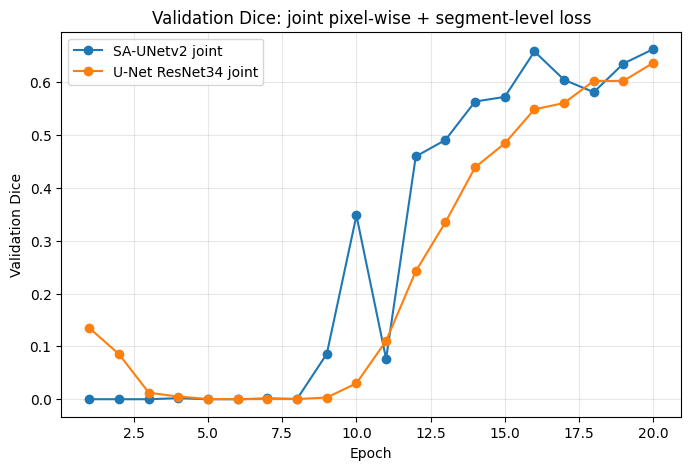

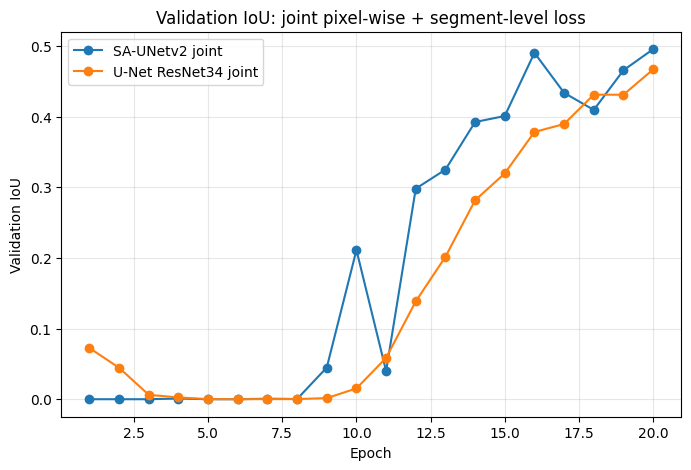

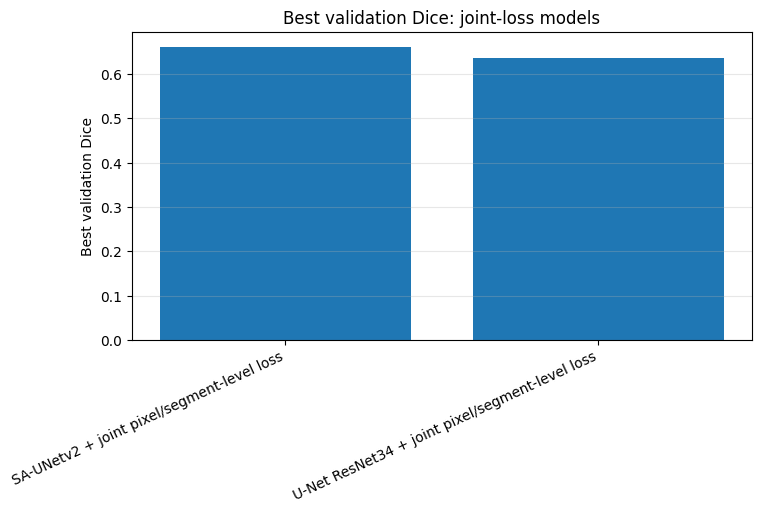

,experiment,checkpoint,used_warm_start,training_initialization,best_epoch,best_val_loss,best_val_dice,best_val_iou,best_val_precision,best_val_recall,best_val_accuracy
1,SA-UNetv2 + joint pixel/segment-level loss,drive_segmentation_project_results/best_saunet...,False,from_scratch,20,0.184275,0.662213,0.495381,0.896030,0.526836,0.929656
0,U-Net ResNet34 + joint pixel/segment-level loss,drive_segmentation_project_results/best_unet_r...,False,from_scratch,20,0.231087,0.636327,0.466715,0.889826,0.495322,0.926065


In [ ]:
history_sources = []

if "unet_joint_history" in globals():
    h = unet_joint_history.copy()
    h["experiment"] = "U-Net ResNet34 joint"
    history_sources.append(h)

if "saunet_joint_history" in globals():
    h = saunet_joint_history.copy()
    h["experiment"] = "SA-UNetv2 joint"
    history_sources.append(h)

if len(history_sources) > 0:
    history_all = pd.concat(history_sources, ignore_index=True)

    plt.figure(figsize=(8, 5))

    for name, group in history_all.groupby("experiment"):
        plt.plot(
            group["epoch"],
            group["val_dice"],
            marker="o",
            label=name
        )

    plt.xlabel("Epoch")
    plt.ylabel("Validation Dice")
    plt.title("Validation Dice: joint pixel-wise + segment-level loss")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))

    for name, group in history_all.groupby("experiment"):
        plt.plot(
            group["epoch"],
            group["val_iou"],
            marker="o",
            label=name
        )

    plt.xlabel("Epoch")
    plt.ylabel("Validation IoU")
    plt.title("Validation IoU: joint pixel-wise + segment-level loss")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

else:
    print("No training histories found. Run block 10 first.")


if "joint_results_df" in globals() and len(joint_results_df) > 0:
    plot_df = joint_results_df.sort_values("best_val_dice", ascending=False)

    plt.figure(figsize=(8, 4))

    plt.bar(
        plot_df["experiment"],
        plot_df["best_val_dice"]
    )

    plt.xticks(rotation=25, ha="right")
    plt.ylabel("Best validation Dice")
    plt.title("Best validation Dice: joint-loss models")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    display(plot_df)

else:
    print("No joint_results_df found. Run block 10 first.")

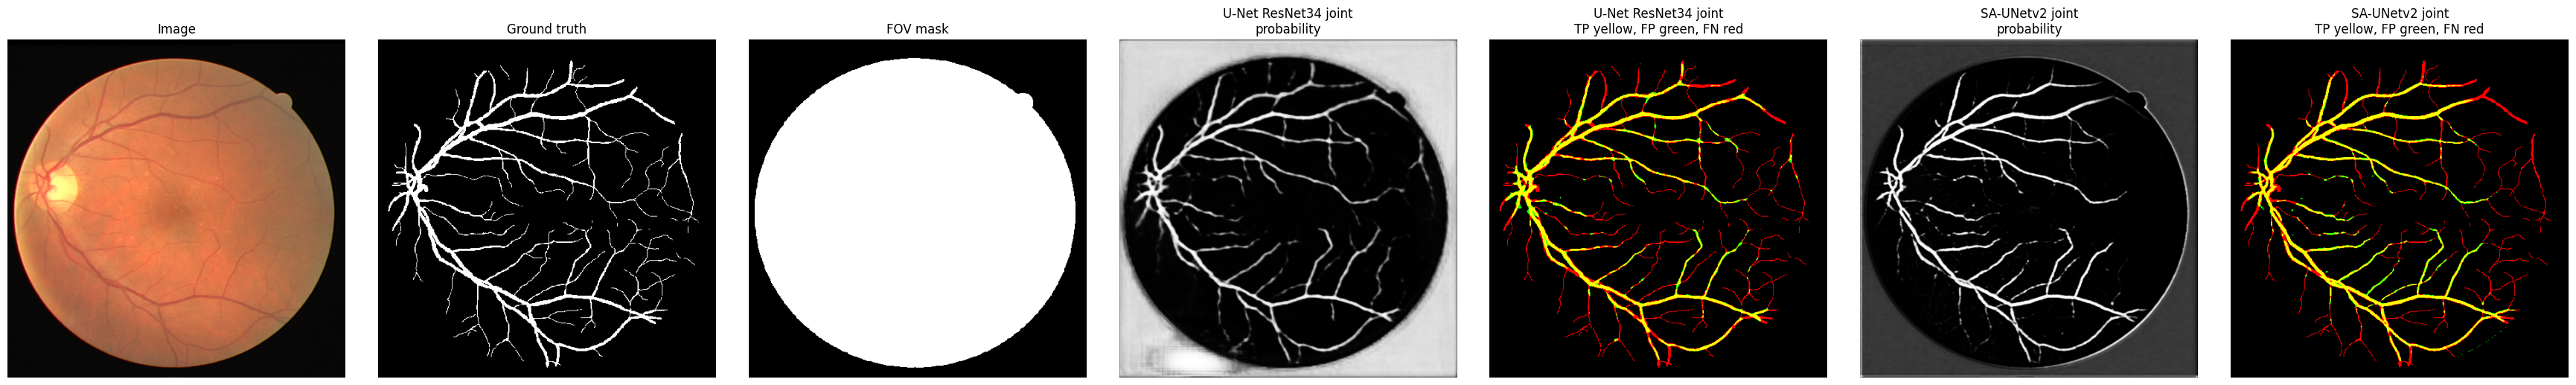

In [ ]:
def load_joint_checkpoint(model, checkpoint_path, device=device):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    else:
        state_dict = checkpoint

    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()

    return model


def predict_joint_mask(model, sample, threshold=0.5, device=device):
    image = sample["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)

        probs = joint_probability(outputs)

        pred = (probs > threshold).float()

    return probs.squeeze().cpu().numpy(), pred.squeeze().cpu().numpy()


def make_error_map(gt_mask, pred_mask, fov_mask):
    gt = gt_mask.astype(bool) & fov_mask.astype(bool)
    pred = pred_mask.astype(bool) & fov_mask.astype(bool)

    error_map = np.zeros((gt.shape[0], gt.shape[1], 3), dtype=np.float32)

    true_positive = gt & pred
    false_positive = (~gt) & pred
    false_negative = gt & (~pred)

    error_map[true_positive] = [1.0, 1.0, 0.0]   # TP: yellow
    error_map[false_positive] = [0.0, 1.0, 0.0]  # FP: green
    error_map[false_negative] = [1.0, 0.0, 0.0]  # FN: red

    return error_map


sample_idx = 0
sample = val_dataset[sample_idx]

models_for_viz = []

unet_joint_ckpt = OUTPUT_DIR / "best_unet_resnet34_joint_segment_pixel.pth"
saunet_joint_ckpt = OUTPUT_DIR / "best_saunetv2_joint_segment_pixel.pth"




if unet_joint_ckpt.exists():
    unet_model_for_viz = UNetResNet34TwoHead(
        encoder_weights=None
    )

    unet_model_for_viz = load_joint_checkpoint(
        unet_model_for_viz,
        unet_joint_ckpt,
        device=device
    )

    models_for_viz.append(
        ("U-Net ResNet34 joint", unet_model_for_viz)
    )




if saunet_joint_ckpt.exists():
    saunet_model_for_viz = SAUNetV2(
        in_channels=3,
        out_channels=2,
        channels=(16, 32, 48, 64),
        drop_prob=0.15,
        block_size=7
    )

    saunet_model_for_viz = load_joint_checkpoint(
        saunet_model_for_viz,
        saunet_joint_ckpt,
        device=device
    )

    models_for_viz.append(
        ("SA-UNetv2 joint", saunet_model_for_viz)
    )



image = denormalize_image(sample["image"])
gt_mask = sample["mask"].squeeze().numpy()
fov_mask = sample["fov"].squeeze().numpy()

n_models = len(models_for_viz)

if n_models == 0:
    print("No trained joint checkpoints found yet. Run block 10 first.")

else:
    n_cols = 3 + 2 * n_models

    plt.figure(figsize=(5 * n_cols, 5))

    plt.subplot(1, n_cols, 1)
    plt.imshow(image)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1, n_cols, 2)
    plt.imshow(gt_mask, cmap="gray")
    plt.title("Ground truth")
    plt.axis("off")

    plt.subplot(1, n_cols, 3)
    plt.imshow(fov_mask, cmap="gray")
    plt.title("FOV mask")
    plt.axis("off")

    col = 4

    for name, model in models_for_viz:
        prob, pred = predict_joint_mask(
            model,
            sample,
            threshold=0.5,
            device=device
        )

        error_map = make_error_map(
            gt_mask=gt_mask,
            pred_mask=pred,
            fov_mask=fov_mask
        )

        plt.subplot(1, n_cols, col)
        plt.imshow(prob, cmap="gray")
        plt.title(f"{name}\nprobability")
        plt.axis("off")
        col += 1

        plt.subplot(1, n_cols, col)
        plt.imshow(error_map)
        plt.title(f"{name}\nTP yellow, FP green, FN red")
        plt.axis("off")
        col += 1

    plt.tight_layout()
    plt.show()

In [ ]:

joint_comparison_path = OUTPUT_DIR / "joint_segment_pixel_loss_comparison.csv"

if not joint_comparison_path.exists():
    raise FileNotFoundError(
        f"Не найден {joint_comparison_path}. Сначала выполни обучение в ячейке 10."
    )

joint_results_df = pd.read_csv(joint_comparison_path)
print("Joint-loss results:")
display(joint_results_df)

# Если в старой папке есть финальная таблица из прошлого ноутбука,
# автоматически добавим к ней новые строки.
old_comparison_candidates = [
    OUTPUT_DIR / "final_all_experiments_comparison.csv",
    OUTPUT_DIR / "loss_level_methods_comparison.csv",
]

old_comparison_path = next((p for p in old_comparison_candidates if p.exists()), None)

if old_comparison_path is not None:
    old_df = pd.read_csv(old_comparison_path)

    # У старой и новой таблицы могут быть разные названия колонок.
    # Поэтому аккуратно объединяем по общему набору и оставляем все колонки.
    combined_df = pd.concat([old_df, joint_results_df], ignore_index=True, sort=False)

    if "best_val_dice" in combined_df.columns:
        combined_df = combined_df.sort_values("best_val_dice", ascending=False)
    elif "dice" in combined_df.columns:
        combined_df = combined_df.sort_values("dice", ascending=False)

    combined_path = OUTPUT_DIR / "final_comparison_with_joint_segment_pixel_loss.csv"
    combined_df.to_csv(combined_path, index=False)

    print("Old comparison used:", old_comparison_path)
    print("Saved combined comparison:", combined_path)
    display(combined_df)
else:
    print("Старая итоговая таблица не найдена. Новые результаты лежат здесь:", joint_comparison_path)


Joint-loss results:


,experiment,checkpoint,used_warm_start,training_initialization,best_epoch,best_val_loss,best_val_dice,best_val_iou,best_val_precision,best_val_recall,best_val_accuracy
0,U-Net ResNet34 + joint pixel/segment-level loss,drive_segmentation_project_results/best_unet_r...,False,from_scratch,20,0.231087,0.636327,0.466715,0.889826,0.495322,0.926065
1,SA-UNetv2 + joint pixel/segment-level loss,drive_segmentation_project_results/best_saunet...,False,from_scratch,20,0.184275,0.662213,0.495381,0.896030,0.526836,0.929656


Старая итоговая таблица не найдена. Новые результаты лежат здесь: drive_segmentation_project_results/joint_segment_pixel_loss_comparison.csv
